# This notebok will create Figures 1 and 2

## Import necessary packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from chromatic import *

/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


## Define some characteristics of either visit and load the table of BJD times

In [2]:
visits = {
    'F21': {
        'Grism': 'G141',
        'BJD_times': np.array(pd.read_csv('F21_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459455.708 * u.day,
        'time_upper': 2459455.738 * u.day,
        'T0 (BJD_TDB)': 2459455.9895 * u.day,
        'exp (s)': 4.9784 * u.s,
        'native resolution': 46.3 * u.angstrom
    },
    'S22': {
        'Grism': 'G102',
        'BJD_times': np.array(pd.read_csv('S22_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459684.215 * u.day,
        'time_upper': 2459684.243 * u.day,
        'T0 (BJD_TDB)': 2459684.4959 * u.day, # This is 27 planetary orbits after the first transit
        'exp (s)': 9.67632 * u.s,
        'native resolution': 24.6 * u.angstrom
    }
}

# Figure 1

F21 Forward



  0%|          | 0/182 [00:00<?, ?it/s]

F21 Reverse



  0%|          | 0/182 [00:00<?, ?it/s]

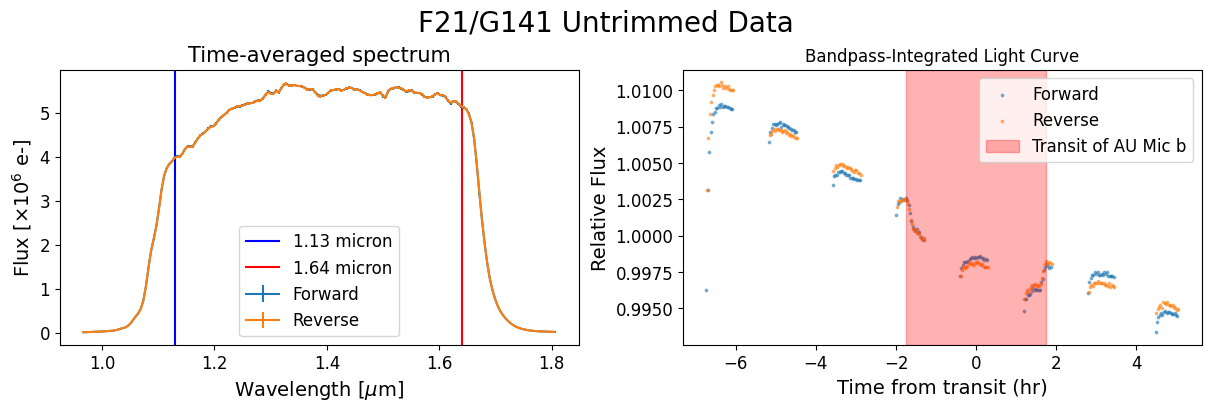

S22 Forward



  0%|          | 0/193 [00:00<?, ?it/s]

S22 Reverse



  0%|          | 0/193 [00:00<?, ?it/s]

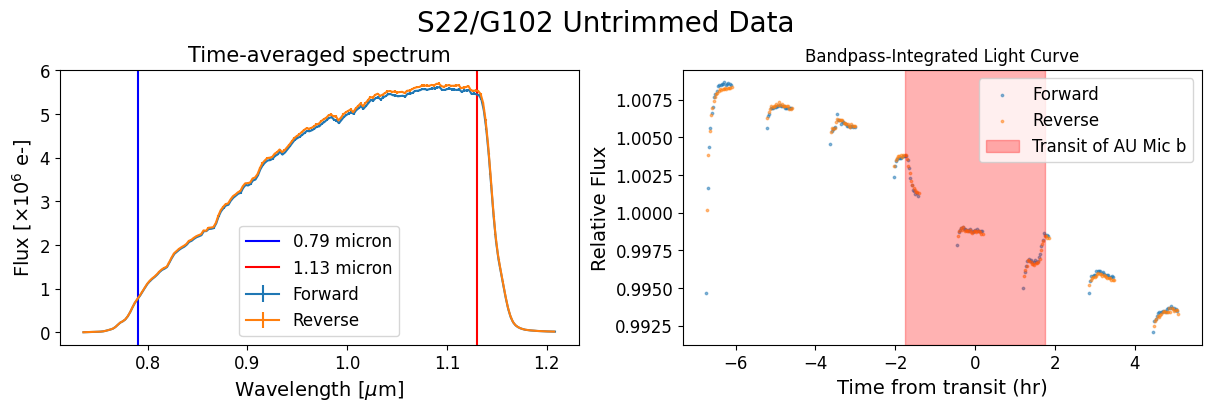

In [3]:
for visit in ['F21','S22']:
    
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))

    for direction in ['Forward','Reverse']:
        print(visit,direction)
        print('')

        'Read in the data from the previous step'
        aligned_rainbow = read_rainbow(f'{visit}_{direction}_aligned_pacman_spec.rainbow.npy')

        'Calculate the average spectrum'
        average_spec = aligned_rainbow.get_average_spectrum()
        average_spec_err = 0.005*average_spec

        visit_data = visits[f'{visit}']        
        grism = visit_data['Grism']
        t0 = visit_data['T0 (BJD_TDB)']
        if visit =='F21':
            wave_lower = 1.13*u.micron # blue-end cutoff for trimming
            wave_upper = 1.64*u.micron # red-end cutoff for trimming
            grism = 'G141'

        if visit =='S22':
            wave_lower = 0.79*u.micron
            wave_upper = 1.13*u.micron
            grism = 'G102'
        
        'Calculate the white light curve'
        white_light_curve = np.nansum(aligned_rainbow.flux, axis=0)
        white_light_curve_err = 30e-6*white_light_curve
        
        'Plot'
        ax1.errorbar(aligned_rainbow.wavelength, average_spec/1e6, yerr=average_spec_err/1e6,label=f'{direction}')
        ax2.scatter((aligned_rainbow.time.value-t0.value)*24, white_light_curve/np.nanmean(white_light_curve[22:]), s=3,alpha=0.5, label=f'{direction}')

    ax1.axvline(wave_lower.value,label=f'{wave_lower.value} micron',color='blue')
    ax1.axvline(wave_upper.value,label=f'{wave_upper.value} micron',color='red')
    ax1.legend(fontsize=12)
    ax1.set_title(f'Time-averaged spectrum',fontsize=15)
    ax1.set_xlabel(r'Wavelength [$\mu$m]',fontsize=14)
    ax1.set_ylabel(r'Flux [$\times10^6$ e-]',fontsize=14)
    
    ax2.axvspan(-1.75, 1.75, alpha=0.3,color='r',label='Transit of AU Mic b')
    ax2.legend(fontsize=12)
    ax2.set_title(f'Bandpass-Integrated Light Curve')
    ax2.set_xlabel(r'Time from transit (hr)',fontsize=14)
    ax2.set_ylabel('Relative Flux',fontsize=14)

    ax1.tick_params(axis='both',labelsize=12)
    ax2.tick_params(axis='both',labelsize=12)
    
    plt.suptitle(f'{visit}/{grism} Untrimmed Data',size=20)
    plt.savefig(f"{visit}_untrimmed_pacman_data.png",dpi=300)
    plt.show()

In [4]:
# Make custom units for the plot labels
megaelectron = u.def_unit(
    ['10^6 e-', 'megaelectron'],  # name
    represents=1e6 * u.electron,   # unit
    format={'latex': r'x10^{6}~e^{-}',  # LaTeX format
        'generic': '10^6 e-'}       # plain text
)
relativeflux = u.def_unit(
    ['Relative Flux', 'relativeflux'], 
    represents=1.0 * u.electron,  
    format={'latex': 'Relative Flux', 
        'generic': 'Relative Flux'}     
)

## Figure 2

🌈🤖 In using`.pcolormesh`, [display pixels] / [data pixels] =
[343. 236.] / [162 181] = [2.11792284 1.30440086] ('Time', 'Wavelength')
Is less than the suggested threshold of 2.

This suggests that aliasing/moiré might be a problem, where too many
data pixels are trying to be displayed with too few pixels, and the
choices `matplotlib` makes for how to do that might not be intuitive.

Here are possible solutions:
    - Use `.bin()` to decrease the number of data pixels in wavelength
    and/or time, effectively averaging before displaying, rather than
    asking `matplotlib` to decide how to visually average adjacent data.
    - Increase the `dpi` of the figure in which this appears, so there are
    enough display pixels to represent all the data pixels being shown.
    - Use `.imshow()` instead of `.pcolormesh`, which can do better
    built-in handling of antialiasing for large data arrays. Since `.imshow()`
    can only show uniform wavelength and time grids, non-uniform grids will
 

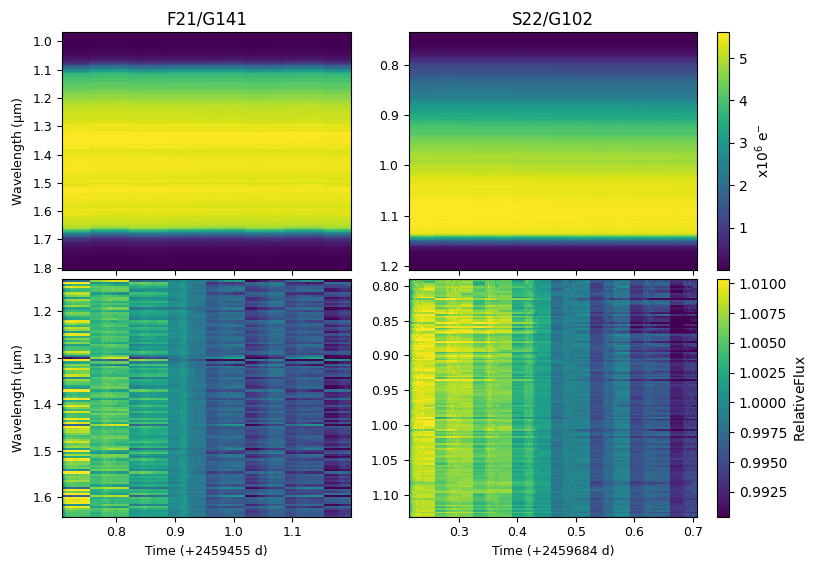

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5.5), sharey=False, sharex='col', 
                         constrained_layout=True)

for visit in ['F21', 'S22']:
    direction = 'Forward'

    'Load data tables'
    visit_data = visits[f'{visit}']        
    t0 = visit_data['T0 (BJD_TDB)']

    if visit == 'F21':
        wave_lower = 1.13 * u.micron  # blue-end cutoff for trimming
        wave_upper = 1.64 * u.micron  # red-end cutoff for trimming
        grism = 'G141'
        time_offset = 2459455 * u.day
        title = 'F21/G141'
        col_idx = 0  # left column

    if visit == 'S22':
        wave_lower = 0.79 * u.micron 
        wave_upper = 1.13 * u.micron 
        grism = 'G102'
        time_offset = 2459684 * u.day
        title = 'S22/G102'
        col_idx = 1  # right column

    aligned_rainbow = read_rainbow(f'{visit}_{direction}_aligned_pacman_spec.rainbow.npy')
    wavelength = aligned_rainbow.wavelength

    'Trim the bad wavelengths from the wavelength and flux arrays'
    a = (wave_upper >= wavelength)
    b = (wavelength >= wave_lower)
    ok_wavelengths = (a == b)  # trim the edges of each spectrum
    wave = wavelength[ok_wavelengths]
    _flux = aligned_rainbow.flux[ok_wavelengths, :]
    unc = aligned_rainbow.uncertainty[ok_wavelengths, :]
    time = aligned_rainbow.time

    # Turn the wavelength-trimmed data into a Rainbow object and save to a file to use later'
    trimmed = Rainbow(wavelength=wave, time=aligned_rainbow.time, flux=_flux, uncertainty=unc)

    for i, wavelength in enumerate(trimmed.wavelength.value):
        this_flux = trimmed.flux[i, :]
        normed_flux = this_flux / np.nanmedian(this_flux)
        trimmed.flux[i, :] = normed_flux * u.electron
    trimmed.flux = trimmed.flux.to(relativeflux)

    # Load and process unaltered data
    unaltered_rainbow = read_rainbow(f'{visit}_{direction}_unaltered_pacman_spec.rainbow.npy')
    # unaltered_rainbow.flux /= 1e6
    unaltered_rainbow.flux = unaltered_rainbow.flux.to(megaelectron)
    unaltered_rainbow.time = unaltered_rainbow.time - time_offset
    
    # Plot unaltered data in top row
    ax_top = axes[0, col_idx]    
    if col_idx == 0:  # Only for left column
        ax_top.set_ylabel(r'Wavelength ($\mu$m)', fontsize=9)
        unaltered_rainbow.paint(ax=ax_top,colorbar=False)
    if col_idx == 1:
        unaltered_rainbow.paint(ax=ax_top)
    ax_top.set_title(title, fontsize=12)
    ax_top.set_xlabel('')
    # Remove x-tick labels from top row
    ax_top.tick_params(axis='x', labelbottom=False)
    ax_top.tick_params(axis='both', labelsize=9)

    # Process and plot trimmed data in bottom row
    trimmed.time = trimmed.time - time_offset
    ax_bottom = axes[1, col_idx]
    if col_idx == 0: 
        ax_bottom.set_ylabel(r'Wavelength ($\mu$m)', fontsize=9)
        trimmed.paint(ax=ax_bottom,colorbar=False)
    if col_idx == 1:
        trimmed.paint(ax=ax_bottom)
        ax_bottom.set_ylabel('')
        ax_top.set_ylabel('')
    ax_bottom.set_xlabel(f'Time (+{time_offset:.0f})', fontsize=9)
    ax_bottom.tick_params(axis='both', labelsize=9)

fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.01, hspace=0, wspace=0.05)

plt.savefig("data-processing-mosaic.png", dpi=600, bbox_inches='tight')
plt.show()